### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [84]:
data = pd.read_csv('data/coupons.csv')

In [85]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [86]:
# Figure out the nulls by columns (list the column names)
nulldata = data.isnull().sum().loc[lambda x: x > 0]
print('nulldata: ', nulldata)
# print('-- x --')

# How many of car=null customers have accepted the coupon
num_cars_null_but_accepted = ( (data['car'].isnull()) ).sum()
print('num_cars_null_but_accepted: ', num_cars_null_but_accepted)

# Figure out the unique values & decide what to replace nulls with
print('car unique values: ', data['car'].unique().tolist())
print('Bar unique values: ', data['Bar'].unique().tolist())
print('CoffeeHouse unique values: ', data['CoffeeHouse'].unique().tolist())
print('CarryAway unique values: ', data['CarryAway'].unique().tolist())
print('RestaurantLessThan20 unique values: ', data['RestaurantLessThan20'].unique().tolist())
print('Restaurant20To50 unique values: ', data['Restaurant20To50'].unique().tolist())


nulldata:  car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64
num_cars_null_but_accepted:  12576
car unique values:  [nan, 'Scooter and motorcycle', 'crossover', 'Mazda5', 'do not drive', 'Car that is too old to install Onstar :D']
Bar unique values:  ['never', 'less1', '1~3', 'gt8', nan, '4~8']
CoffeeHouse unique values:  ['never', 'less1', '4~8', '1~3', 'gt8', nan]
CarryAway unique values:  [nan, '4~8', '1~3', 'gt8', 'less1', 'never']
RestaurantLessThan20 unique values:  ['4~8', '1~3', 'less1', 'gt8', nan, 'never']
Restaurant20To50 unique values:  ['1~3', 'less1', 'never', 'gt8', '4~8', nan]


3. Decide what to do about your missing data -- drop, replace, other...

In [87]:
# The percentage of null values is too less. Replacing null values with 'never' is better than removing those rows
# More data is always better
data.fillna({
        'car': 'do not drive',
        'Bar': 'never',
        'CoffeeHouse': 'never',
        'CarryAway': 'never',
        'RestaurantLessThan20': 'never',
        'Restaurant20To50': 'never'
    }, 
    inplace=True
)

# All should be 0 now
nulldata = data.isnull().sum().loc[lambda x: x > 0]
print('This should be empty: ', nulldata)

This should be empty:  Series([], dtype: int64)


4. What proportion of the total observations chose to accept the coupon?



In [88]:
accepted = (data['Y'] == 1).mean() * 100
print(f'% accepted = {accepted:.2f}')

% accepted = 56.84


5. Use a bar plot to visualize the `coupon` column.

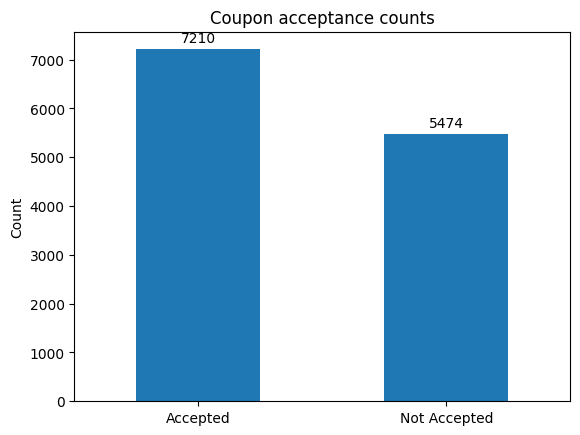

In [89]:
counts = data['Y'].value_counts()
counts

plot = counts.plot(kind='bar', rot=0, title='Coupon acceptance counts')
plot.set_xticklabels(['Accepted', 'Not Accepted'])
plot.bar_label(plot.containers[0], padding=3)

plt.xlabel('')
plt.ylabel('Count')
plt.show()

6. Use a histogram to visualize the temperature column.

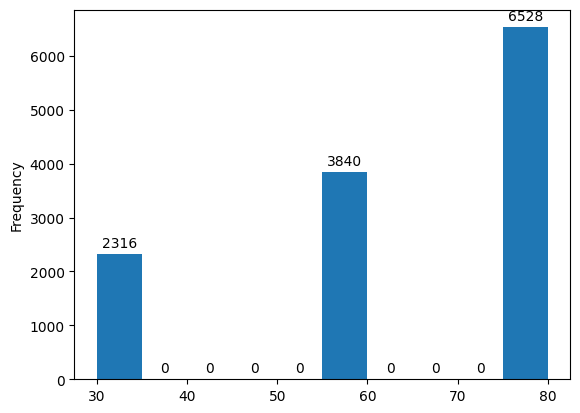

In [90]:
plot = data['temperature'].plot(kind='hist')
plot.bar_label(plot.containers[0], padding=3)

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [91]:
bar = data[ data['coupon'] == 'Bar' ].copy()


2. What proportion of bar coupons were accepted?


In [92]:
accepted = (bar['Y'] == 1).mean() * 100
print(f'% accepted = {accepted:.2f} %')

% accepted = 41.00 %


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Coupon acceptance if went to bar more than 3 times             = 76.88 %
Coupon acceptance if went to bar less than or equal to 3 times = 37.07 %


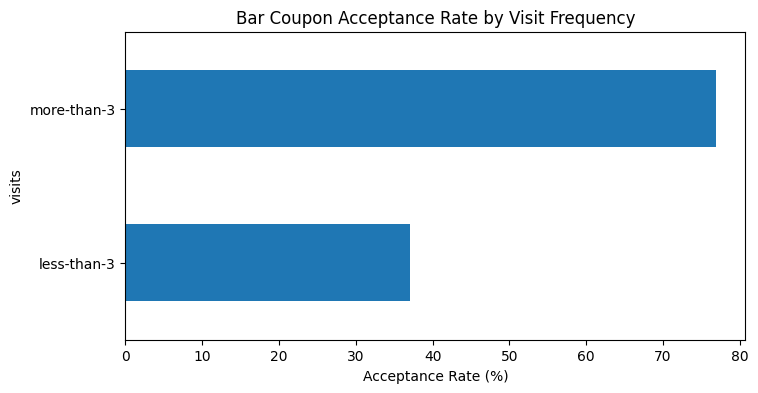

In [93]:
#bar['Bar'].unique()

# Below are considered 3-or-less-than-3
fewer = ['never', 'less1', '1~3']

# Create a new column & use a lambda to fill with values less-than-3 & more-than-3
bar['visits'] = bar['Bar'].apply(lambda x: 'less-than-3' if x in fewer else 'more-than-3')

# Acceptance rates
acceptance_rates = (bar.groupby('visits')['Y'].mean() * 100).round(2)
print(f'Coupon acceptance if went to bar more than 3 times             = {acceptance_rates['more-than-3']} %')
print(f'Coupon acceptance if went to bar less than or equal to 3 times = {acceptance_rates['less-than-3']} %')

acceptance_rates.plot(kind='barh', figsize=(8, 4))
plt.xlabel('Acceptance Rate (%)')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency')
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Bar unique values:  ['never', 'less1', '1~3', 'gt8', '4~8']
Age unique values:  ['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Acceptance rate for people older than 25 and went to bar more than 1 time = 69.52 %
Overall coupon acceptance in entire dataset = 56.84%
YES, there is a difference. Coupons are more used by the bar going individuals compared to the overall population


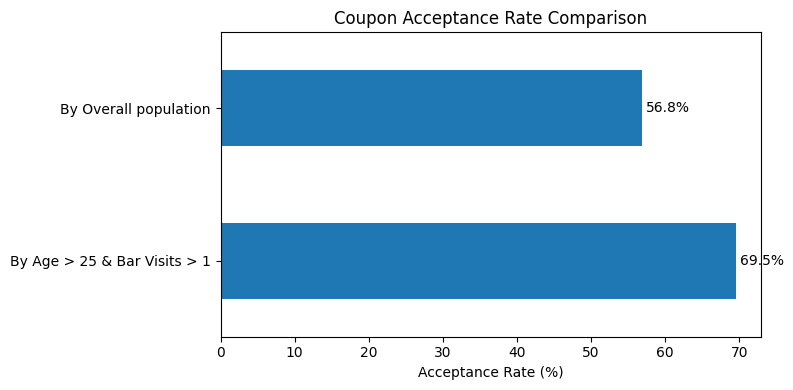

In [94]:
print('Bar unique values: ', bar['Bar'].unique().tolist())
print('Age unique values: ', bar['age'].unique().tolist())

# Let's convert age column to integer
# bar['age'] unique values are ['21', '46', '26', '31', '41', '50plus', '36', 'below21']. Lets write a lambda to convert '50plus' to 55 and 'below21' to 20, then convert the whole column to int
def convert_age(age):
    if age == '50plus':
        return 55
    elif age == 'below21':
        return 20
    else:
        return int(age)   
bar['age'] = bar['age'].apply(convert_age)

# Find bar going people who are older than 25
bar_going_25 = bar[ (bar['age'] > 25) & (bar['Bar'] != 'never') & (bar['Bar'] != 'less1') ]
bar_going_25_accepted = (bar_going_25['Y'] == 1).mean() * 100     # bar_going who accepted coupon

print(f'Acceptance rate for people older than 25 and went to bar more than 1 time = {bar_going_25_accepted:.2f} %')

# Since Y is 0, 1 just the mean will give percentage
total_accepted = (data['Y']).mean() * 100
print(f'Overall coupon acceptance in entire dataset = {total_accepted:.2f}%')

print("YES, there is a difference. Coupons are more used by the bar going individuals compared to the overall population")

# Create a horizontal bar plot comparing the two acceptance rates
comparison_data = pd.Series({
    'By Age > 25 & Bar Visits > 1': bar_going_25_accepted,
    'By Overall population': total_accepted
})

ax = comparison_data.plot(kind='barh', figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate Comparison')
plt.tight_layout()
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate for drivers who go to bars more than once and had adult passengers and had occupations other than farming, fishing or forestry = 71.79 %


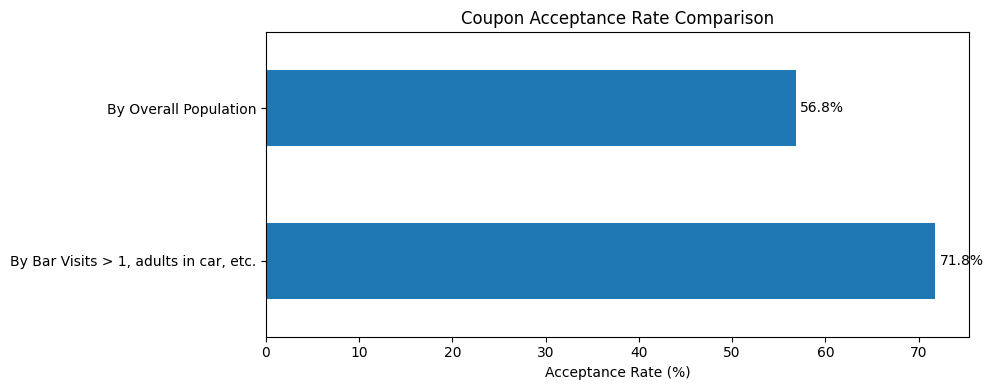

In [95]:
pass_types = ['Kid(s)', 'Alone', 'Friend(s)', 'Partner']

# Filter bar h=going first
bar_going = bar[ (bar['Bar'] != 'never') & (bar['Bar'] != 'less1') ]

# Filter by passenger type (avoid alone & kids)
bar_going_passenger = bar_going[ bar_going['passanger'].isin(['Friend(s)', 'Partner']) ]

# Filter by occupation
bar_going_passenger_occupation = bar_going_passenger[ ~bar_going_passenger['occupation'].isin(['farming', 'fishing', 'forestry']) ]

# Acceptance rate
acceptance_rate = (bar_going_passenger_occupation['Y'] == 1).mean() * 100
print(f'Acceptance rate for drivers who go to bars more than once and had adult passengers and had occupations other than farming, fishing or forestry = {acceptance_rate:.2f} %')

bar_going_adults_profession_accepted = acceptance_rate

# Create a horizontal bar plot comparing the two acceptance rates
comparison_data = pd.Series({
    'By Bar Visits > 1, adults in car, etc.': acceptance_rate,
    'By Overall Population': total_accepted
})

ax = comparison_data.plot(kind='barh', figsize=(10, 4))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate Comparison')
plt.tight_layout()
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [96]:
# Filter bar h=going first
bar_going = bar[ (bar['Bar'] != 'never') & (bar['Bar'] != 'less1') ]

# Filter by passenger type (avoid alone & kids)
bar_going_passenger = bar_going[ bar_going['passanger'].isin(['Friend(s)', 'Partner']) ]

# maritalStatus: ['Unmarried partner', 'Single', 'Married partner', 'Divorced', 'Widowed']

# Filter "not widowed"
bar_going_passenger_marital_status = bar_going_passenger[ bar_going_passenger['maritalStatus'] != 'Widowed' ]

# Acceptance rate
acceptance_rate = (bar_going_passenger_marital_status['Y'] == 1).mean() * 100
print(f'Acceptance rate for drivers who go to bars more than once and accompanied by adult passengers and had marital status other than Widowed = {acceptance_rate:.2f} %')

# Bar going but under age 30
bar_going_under_30 = bar_going[ bar_going['age'] < 30 ]
bar_going_under_30_accepted = (bar_going_under_30['Y'] == 1).mean() * 100     # bar_going who accepted coupon
print(f'Acceptance rate for drivers who go to bars more than once and are under 30 = {bar_going_under_30_accepted:.2f} %')

bar['income'].unique()
income_vals = [ '$37500 - $49999',  '$62500 - $74999',  '$12500 - $24999',
  '$75000 - $87499',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']

# Create a new income_less_than column & use a lambda to fill with values with the max of the range
# Note that this is for the original data dataframe (not for bar going)
def convert_income(income):
    if income == 'Less than $12500':
        return 12500
    elif income == '$100000 or More':
        return 100000
    else:
        return int(income.split(' - ')[1].replace('$', '').replace(',', ''))
data['income_less_than'] = data['income'].apply(convert_income)

# Going to cheap restaurants more than 4 times (from the list of ['4~8', '1~3', 'less1', 'gt8', 'never'])
cheap_restaurants = data[data['RestaurantLessThan20'].isin(['4~8', 'gt8'])]

# Filer above by income less than 50k
cheap_restaurants_income = cheap_restaurants[ cheap_restaurants['income_less_than'] < 50000 ]

# Acceptance rate
acceptance_rate = (cheap_restaurants_income['Y'] == 1).mean() * 100
print(f'Acceptance rate for drivers who go to cheap restaurants more than 4 times a month and have income less than 50k = {acceptance_rate:.2f} %')



Acceptance rate for drivers who go to bars more than once and accompanied by adult passengers and had marital status other than Widowed = 71.79 %
Acceptance rate for drivers who go to bars more than once and are under 30 = 72.17 %
Acceptance rate for drivers who go to cheap restaurants more than 4 times a month and have income less than 50k = 60.07 %


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

It seems like younger people (less than 30) who go to bars atleast once a month use the coupons the most - about 72%. If people are stopping by your bar on their way home, you are better off offering them coupons on their current visit (repeat customers)

People who went to bars more than 3 times also have a very high acceptance rate - at 76%



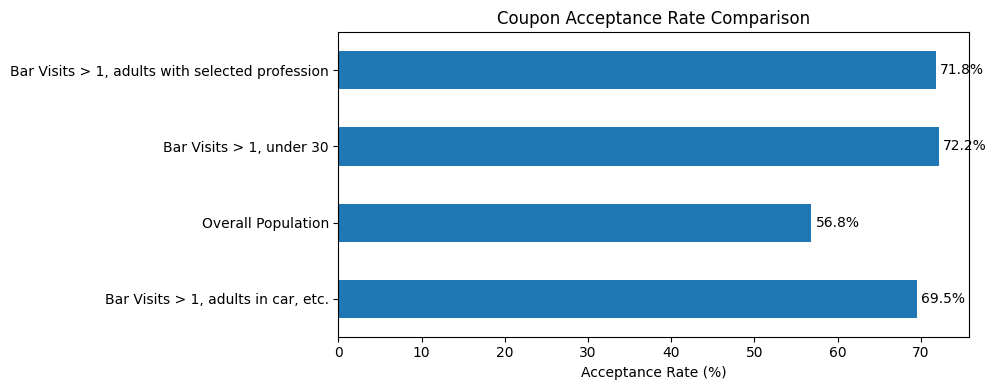

In [97]:
# Create a horizontal bar plot comparing the two acceptance rates
comparison_data = pd.Series({
    'Bar Visits > 1, adults in car, etc.': bar_going_25_accepted,
    'Overall Population': total_accepted,
    'Bar Visits > 1, under 30': bar_going_under_30_accepted,
    'Bar Visits > 1, adults with selected profession': bar_going_adults_profession_accepted
})

ax = comparison_data.plot(kind='barh', figsize=(10, 4))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate Comparison')
plt.tight_layout()
plt.show()

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Understanding the given data through some pie charts


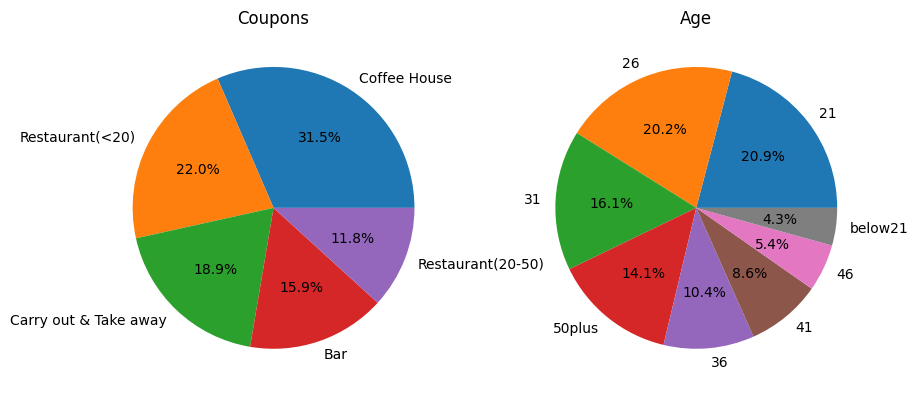

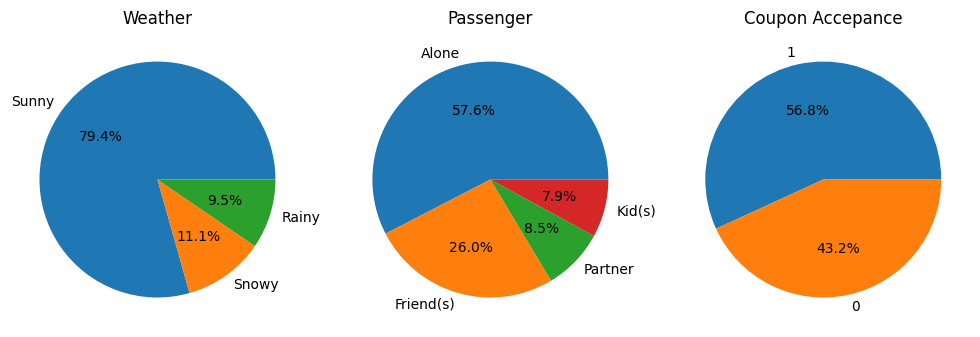

In [98]:

print("Understanding the given data through some pie charts")

# Row 1
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(data['coupon'].value_counts(), labels=data['coupon'].value_counts().index, autopct='%1.1f%%')
axes[0].set_title('Coupons')

axes[1].pie(data['age'].value_counts(), labels=data['age'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Age')

# Row 2
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].pie(data['weather'].value_counts(), labels=data['weather'].value_counts().index, autopct='%1.1f%%')
axes[0].set_title('Weather')

axes[1].pie(data['passanger'].value_counts(), labels=data['passanger'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Passenger')

axes[2].pie(data['Y'].value_counts(), labels=data['Y'].value_counts().index, autopct='%1.1f%%')
axes[2].set_title('Coupon Accepance')

plt.tight_layout()
plt.show()

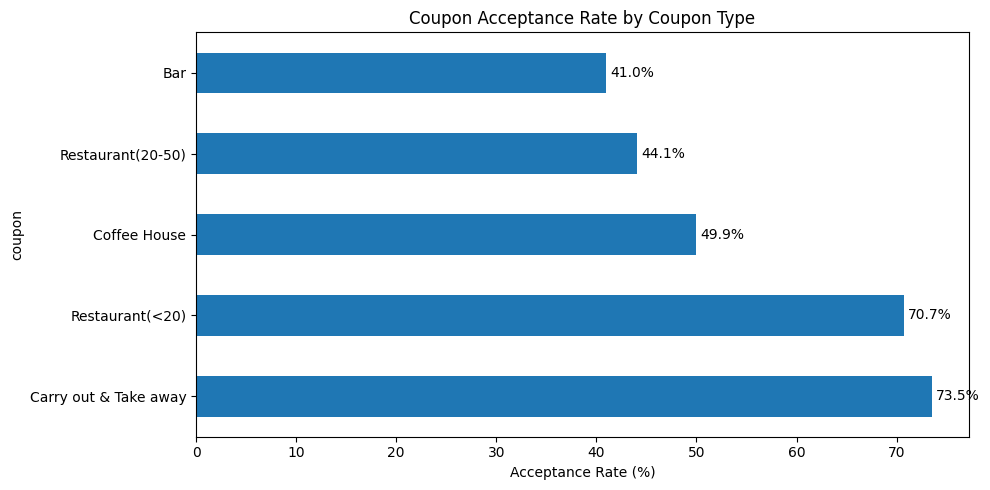

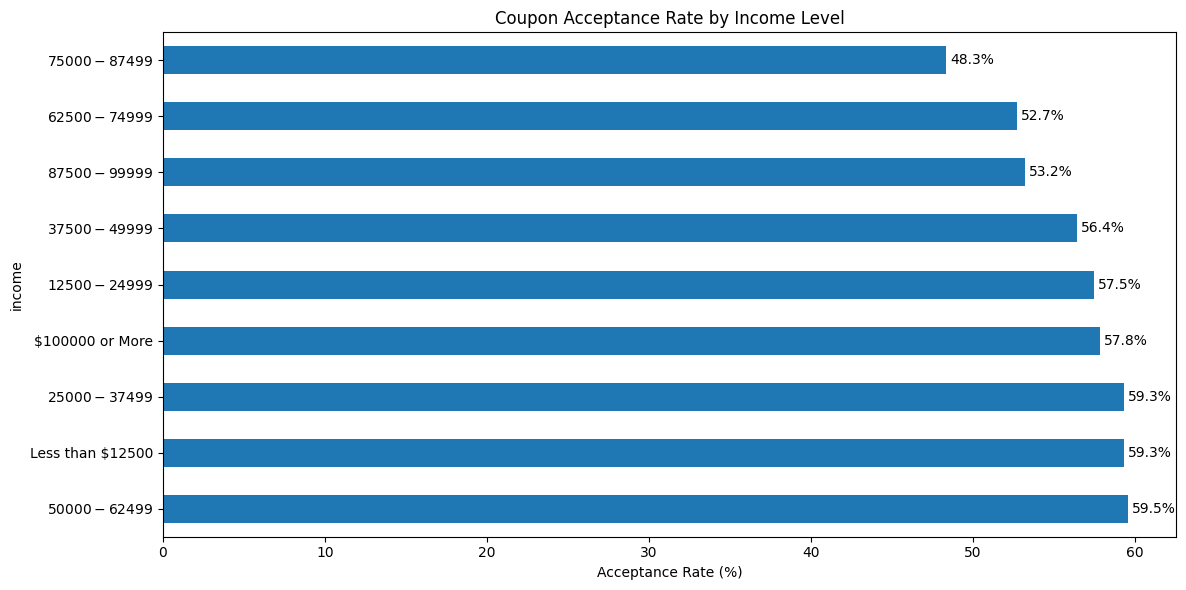

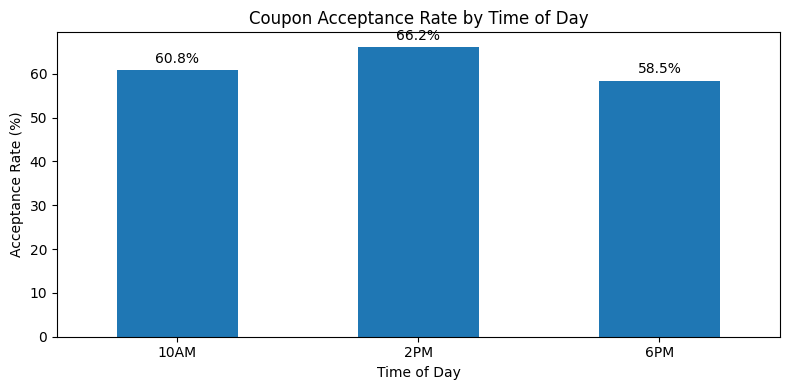

In [99]:
# Acceptance by Coupon Type
coupon_acceptance = (data.groupby('coupon')['Y'].mean() * 100).round(2)
coupon_acceptance = coupon_acceptance.sort_values(ascending=False)

ax = coupon_acceptance.plot(kind='barh', figsize=(10, 5))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Coupon Type')
plt.tight_layout()
plt.show()

# Acceptance by Income
income_acceptance = (data.groupby('income')['Y'].mean() * 100).round(2)
income_acceptance = income_acceptance.sort_values(ascending=False)

ax = income_acceptance.plot(kind='barh', figsize=(12, 6))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Income Level')
plt.tight_layout()
plt.show()

# Acceptance by Time of Day
time_acceptance = (data.groupby('time')['Y'].mean() * 100).round(2)
time_acceptance = time_acceptance.reindex(['10AM', '2PM', '6PM'])  # Order chronologically

ax = time_acceptance.plot(kind='bar', figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Time of Day')
plt.ylabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Time of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

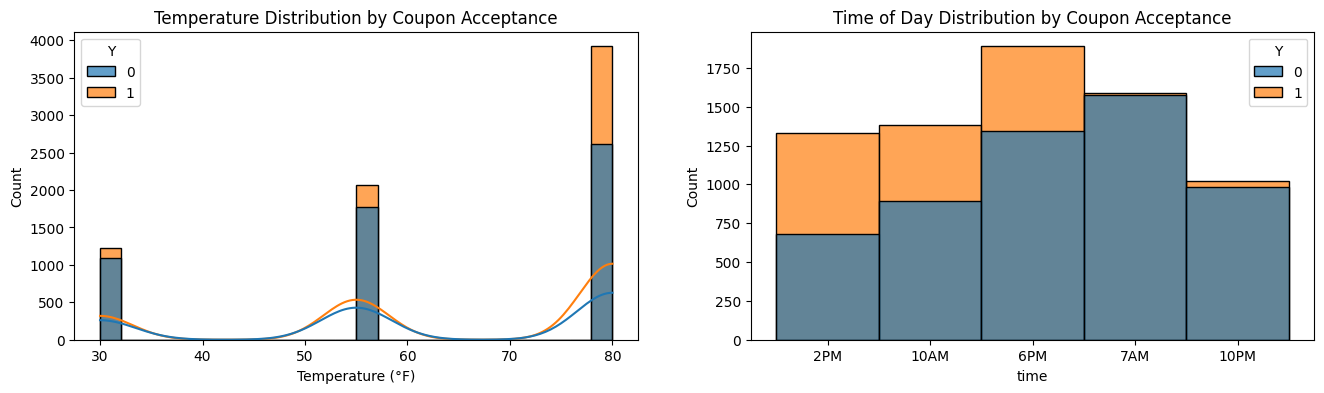

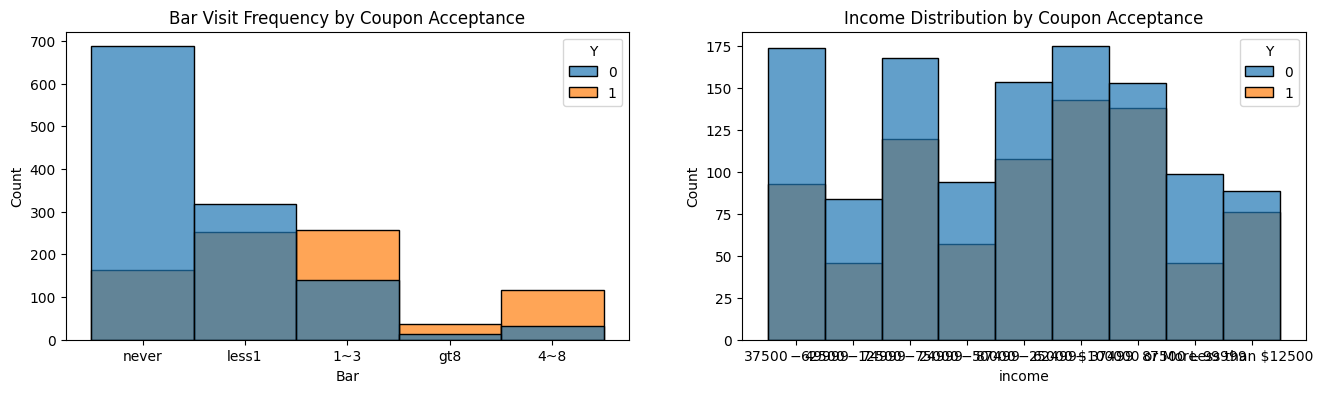

In [100]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Distribution of Temperature by Coupon Acceptance
sns.histplot(data=data, x='temperature', hue='Y', kde=True, stat='count', ax=axes[0], alpha=0.7)
axes[0].set_title('Temperature Distribution by Coupon Acceptance')
axes[0].set_xlabel('Temperature (°F)')

# Distribution of Time by Coupon Acceptance
sns.histplot(data=data, x='time', hue='Y', kde=False, stat='count', ax=axes[1], alpha=0.7)
axes[1].set_title('Time of Day Distribution by Coupon Acceptance')


fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Distribution of Bar Visit Frequency by Acceptance
sns.histplot(data=bar, x='Bar', hue='Y', kde=False, alpha=0.7, ax=axes[0])
axes[0].set_title('Bar Visit Frequency by Coupon Acceptance')

sns.histplot(data=bar, x='income', hue='Y', kde=False, alpha=0.7, ax=axes[1])
axes[1].set_title('Income Distribution by Coupon Acceptance')

plt.show()


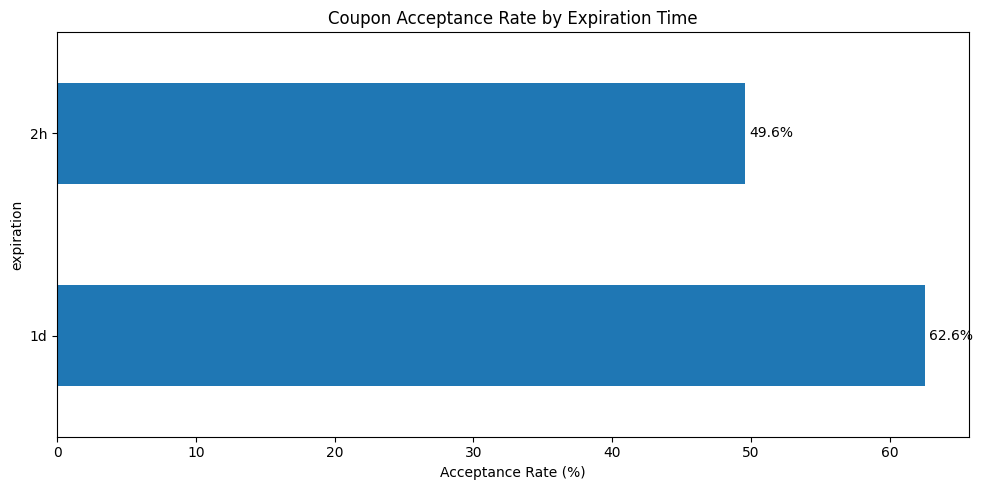

In [105]:
# Do people who have coupons that expire sooner accept them more than those with later expiration? Let's find out.
expiration_acceptance = (data.groupby('expiration')['Y'].mean() * 100).round(2)
expiration_acceptance = expiration_acceptance.sort_values(ascending=False)
ax = expiration_acceptance.plot(kind='barh', figsize=(10, 5))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel('Acceptance Rate (%)')
plt.title('Coupon Acceptance Rate by Expiration Time')
plt.tight_layout()
plt.show()
